In [ ]:
# Step 1: Install and import dependencies
!pip install kagglehub --quiet
import kagglehub
import pandas as pd
import numpy as np


In [ ]:
# Step 2: Download dataset using kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load the CSV file into a DataFrame
data = pd.read_csv(f"{path}/creditcard.csv")

# Show the first 5 rows
data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drop the 'Time' column
data = data.drop(columns=['Time'])

# Scale the 'Amount' column
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])

# Separate features and target
X = data.drop(columns=['Class'])
y = data['Class']

# Split into train and test sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Confirm split sizes
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (227845, 29)
Test set size: (56962, 29)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr, digits=4))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression Performance:
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

AUC-ROC: 0.9559728259621236


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train Random Forest using all CPU cores
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf, digits=4))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Performance:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9419    0.8265    0.8804        98

    accuracy                         0.9996     56962
   macro avg     0.9708    0.9132    0.9401     56962
weighted avg     0.9996    0.9996    0.9996     56962

AUC-ROC: 0.9528106983508091


In [ ]:
from sklearn.svm import SVC

# Sample 5000 rows from each class (stratified)
X_svm, _, y_svm, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42)

# Train SVM with RBF kernel
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_svm, y_svm)

# Predict on test set
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Evaluate
print("SVM (RBF Kernel) Performance:")
print(classification_report(y_test, y_pred_svm, digits=4))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_svm))


SVM (RBF Kernel) Performance:
              precision    recall  f1-score   support

           0     0.9986    1.0000    0.9993     56864
           1     0.9444    0.1735    0.2931        98

    accuracy                         0.9986     56962
   macro avg     0.9715    0.5867    0.6462     56962
weighted avg     0.9985    0.9986    0.9981     56962

AUC-ROC: 0.9562640686550365


In [ ]:
# Install xgboost if not already installed
!pip install xgboost --quiet


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# Create and train the XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:33:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Performance:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8901    0.8265    0.8571        98

    accuracy                         0.9995     56962
   macro avg     0.9449    0.9132    0.9285     56962
weighted avg     0.9995    0.9995    0.9995     56962

AUC-ROC: 0.9711382618607376


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Initialize Isolation Forest with corrected contamination argument
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)

# Fit the model
iso_forest.fit(X_train)

# Predict anomalies on test set
y_pred_iso = iso_forest.predict(X_test)

# Convert prediction to binary: anomaly = 1, normal = 0
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("Isolation Forest ---")
print(classification_report(y_test, y_pred_iso))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_iso))




Isolation Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56797    67]
 [   66    32]]


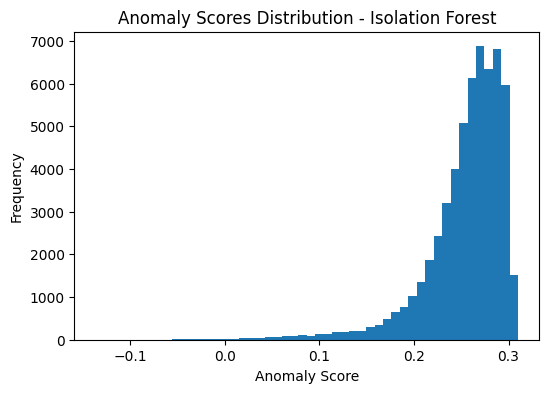

In [ ]:
import matplotlib.pyplot as plt

def plot_anomaly_scores(model, X, model_name):
    scores = model.decision_function(X)

    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=50)
    plt.title(f'Anomaly Scores Distribution - {model_name}')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.show()

plot_anomaly_scores(iso_forest, X_test, "Isolation Forest")


In [ ]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score

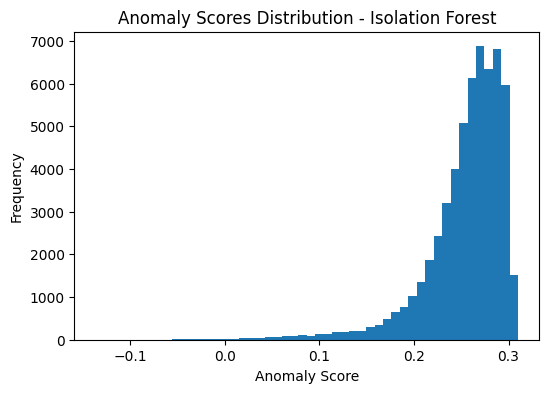

In [ ]:
import matplotlib.pyplot as plt

def plot_anomaly_scores(model, X, model_name):
    scores = model.decision_function(X)

    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=50)
    plt.title(f'Anomaly Scores Distribution - {model_name}')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.show()

plot_anomaly_scores(iso_forest, X_test, "Isolation Forest")

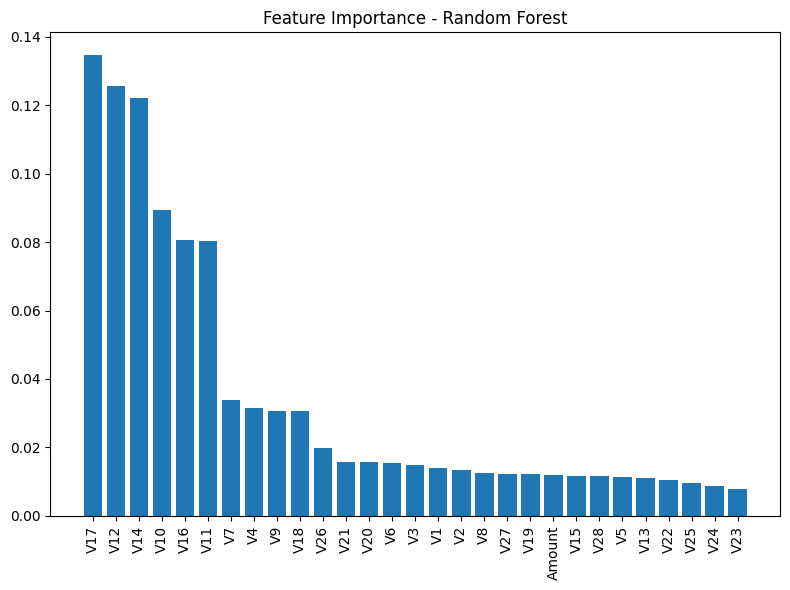

In [ ]:
import matplotlib.pyplot as plt
# Define feature names from the training data
feature_names = X_train.columns.tolist()

# Plot feature importance
plot_feature_importance(rf_model, feature_names, "Random Forest")

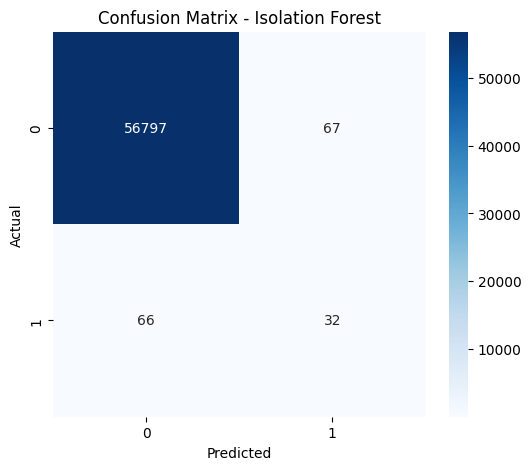

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Example usage:
plot_confusion_matrix(y_test, y_pred_iso, "Isolation Forest")


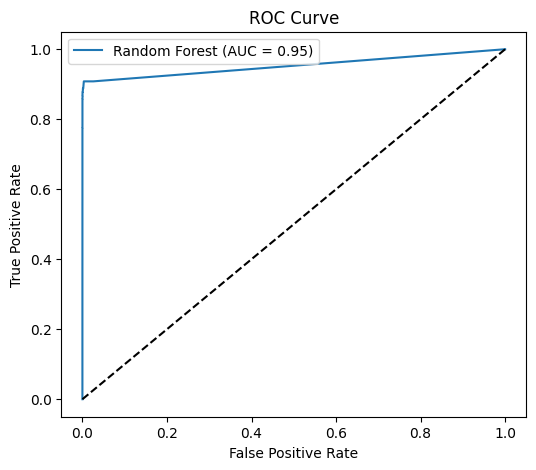

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test, y_test, model_name):
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print(f"No probability or decision function for {model_name}")
        return

    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

# Example for Random Forest (after training rf_model)
plot_roc_curve(rf_model, X_test, y_test, "Random Forest")


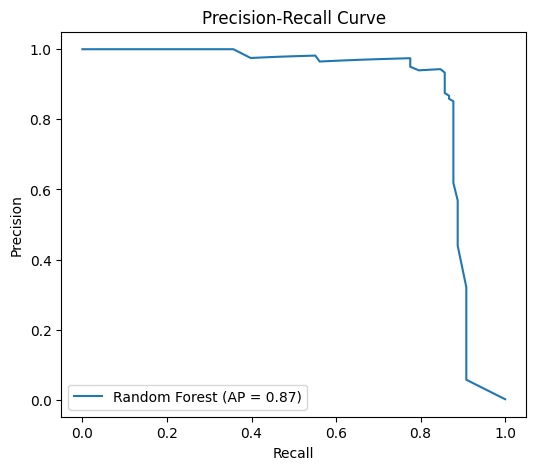

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(model, X_test, y_test, model_name):
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print(f"No probability or decision function for {model_name}")
        return

    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    avg_precision = average_precision_score(y_test, y_scores)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

plot_precision_recall(rf_model, X_test, y_test, "Random Forest")


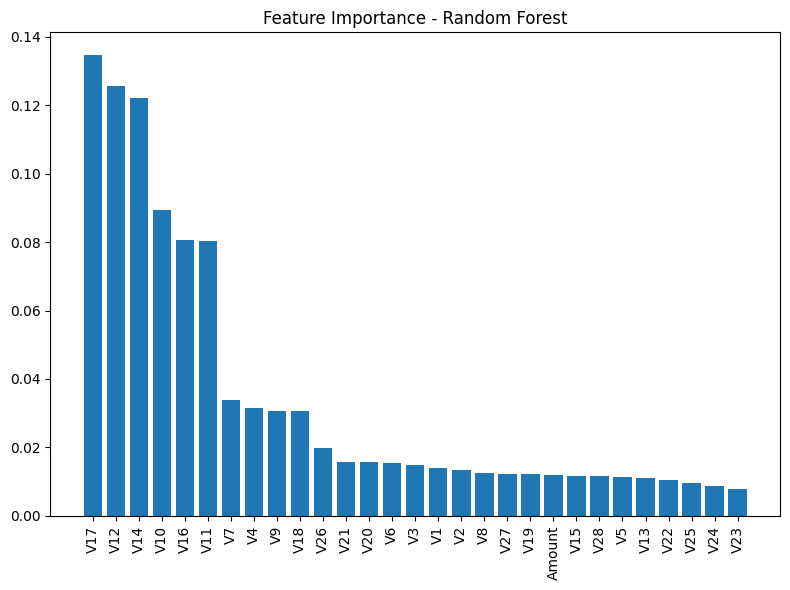

In [ ]:
def plot_feature_importance(model, feature_names, model_name):
    importances = model.feature_importances_
    indices = importances.argsort()[::-1]

    plt.figure(figsize=(8,6))
    plt.title(f'Feature Importance - {model_name}')
    plt.bar(range(len(importances)), importances[indices], align='center')
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_feature_importance(rf_model, feature_names, "Random Forest")


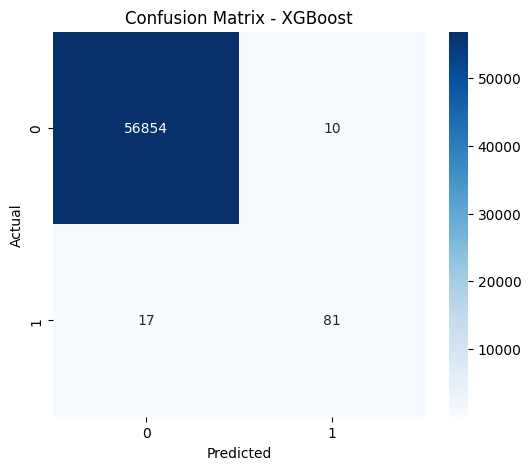

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost")


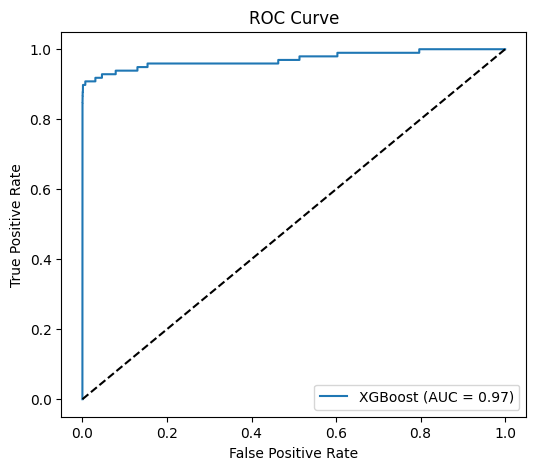

In [ ]:
plot_roc_curve(xgb_model, X_test, y_test, "XGBoost")

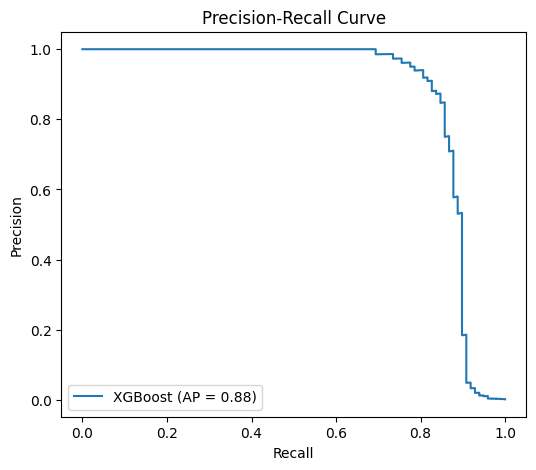

In [ ]:
plot_precision_recall(xgb_model, X_test, y_test, "XGBoost")

In [ ]:
# Required libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Train the models
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

# Step 2: Store models in a dictionary
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "SVM": svm_model
}

# Step 3: Define function to summarize performance
def summarize_models(models, X_test, y_test):
    results = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1 Score': f1_score(y_test, y_pred)
        })
    return pd.DataFrame(results)

# Step 4: Call function to generate summary
summary_df = summarize_models(models, X_test, y_test)
print(summary_df)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:11:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
